# TotalSegmentor

Combined lung voxels: 13068271
Saved:
combined_lung_mask.nii.gz
lung_only_ct.nii.gz


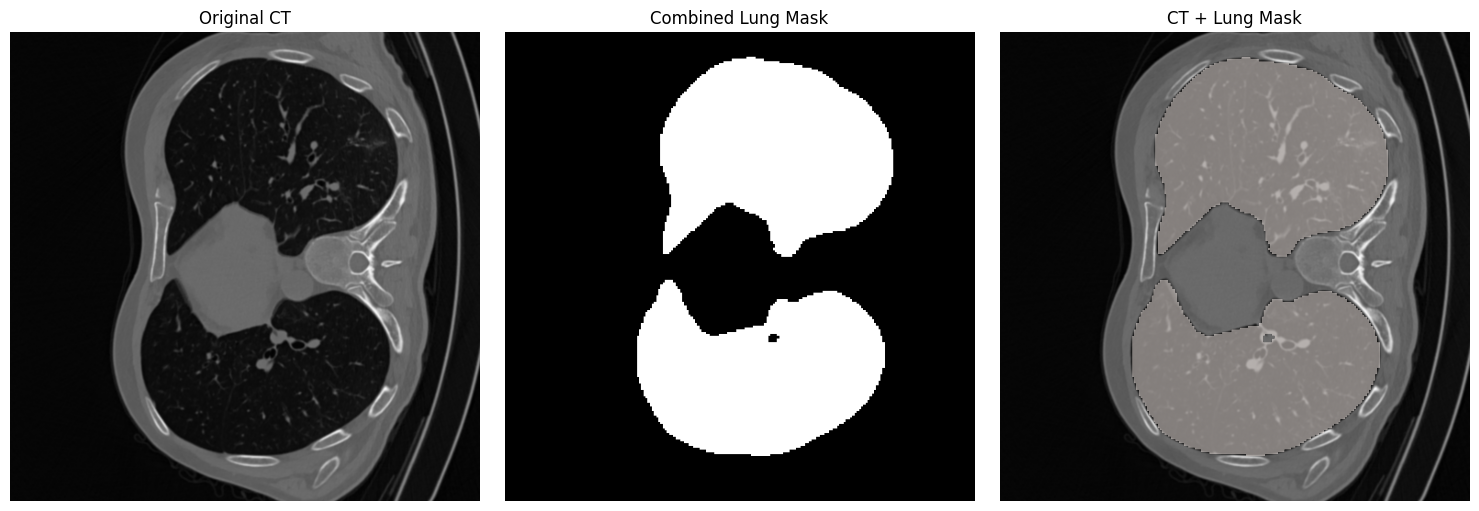

In [ ]:
import os
import nibabel as nib
import numpy as np
%matplotlib inline


# ============================
# Paths
# ============================

ct_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_122_b_1.nii.gz"

output_dir = r"./totalseg_output"



# ============================
# Load CT
# ============================

ct_img = nib.load(ct_path)

ct = ct_img.get_fdata()



# ============================
# Combine lung lobe masks
# ============================

lung_files = [
    "lung_upper_lobe_left.nii.gz",
    "lung_lower_lobe_left.nii.gz",
    "lung_upper_lobe_right.nii.gz",
    "lung_middle_lobe_right.nii.gz",
    "lung_lower_lobe_right.nii.gz"
]


# empty mask

lung_mask = np.zeros(
    ct.shape,
    dtype=bool
)


for file in lung_files:

    mask_path = os.path.join(
        output_dir,
        file
    )

    mask = nib.load(mask_path).get_fdata() > 0

    lung_mask = lung_mask | mask



print("Combined lung voxels:", lung_mask.sum())



# ============================
# Apply lung mask
# ============================

lung_only_ct = ct.copy()

lung_only_ct[
    ~lung_mask
] = -1000



# ============================
# Save combined mask
# ============================

mask_img = nib.Nifti1Image(
    lung_mask.astype(np.uint8),
    ct_img.affine,
    ct_img.header
)


nib.save(
    mask_img,
    "combined_lung_mask.nii.gz"
)



lung_img = nib.Nifti1Image(
    lung_only_ct,
    ct_img.affine,
    ct_img.header
)


nib.save(
    lung_img,
    "lung_only_ct.nii.gz"
)


print("Saved:")
print("combined_lung_mask.nii.gz")
print("lung_only_ct.nii.gz")



# ============================
# Visualization
# ============================

slice_idx = np.argmax(
    lung_mask.sum(axis=(0,1))
)


plt.figure(figsize=(15,5))


# Original

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title("Original CT")

plt.axis("off")



# Mask

plt.subplot(1,3,2)

plt.imshow(
    lung_mask[:,:,slice_idx],
    cmap="gray"
)

plt.title("Combined Lung Mask")

plt.axis("off")



# Overlay

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        lung_mask[:,:,slice_idx]==0,
        lung_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.5
)


plt.title("CT + Lung Mask")

plt.axis("off")


plt.tight_layout()

plt.show()

# LungMask

In [5]:
from lungmask import LMInferer
import SimpleITK as sitk

inferer = LMInferer()

input_image = sitk.ReadImage("/home/chest_ct/code/data/data_volumes/dataset/train_fixed/valid_342_a_2.nii.gz")
segmentation = inferer.apply(input_image)

 95%|█████████▍| 12/12.65 [00:00<00:00, 18.98it/s]/home/chest_ct/code/.venv/lib/python3.12/site-packages/tqdm/std.py:635: TqdmWarning: clamping frac to range [0, 1]
  full_bar = Bar(frac,
103%|██████████| 13/12.65 [00:00<-00:00, 19.64it/s]

lungmask 2026-07-31 16:31:38 Postprocessing



100%|██████████| 5/5 [00:00<00:00, 1622.81it/s]


Raw GT shape: (6, 512, 512, 253)
GT shape: (253, 512, 512)
CT shape: (253, 512, 512)
Widest slice: 135


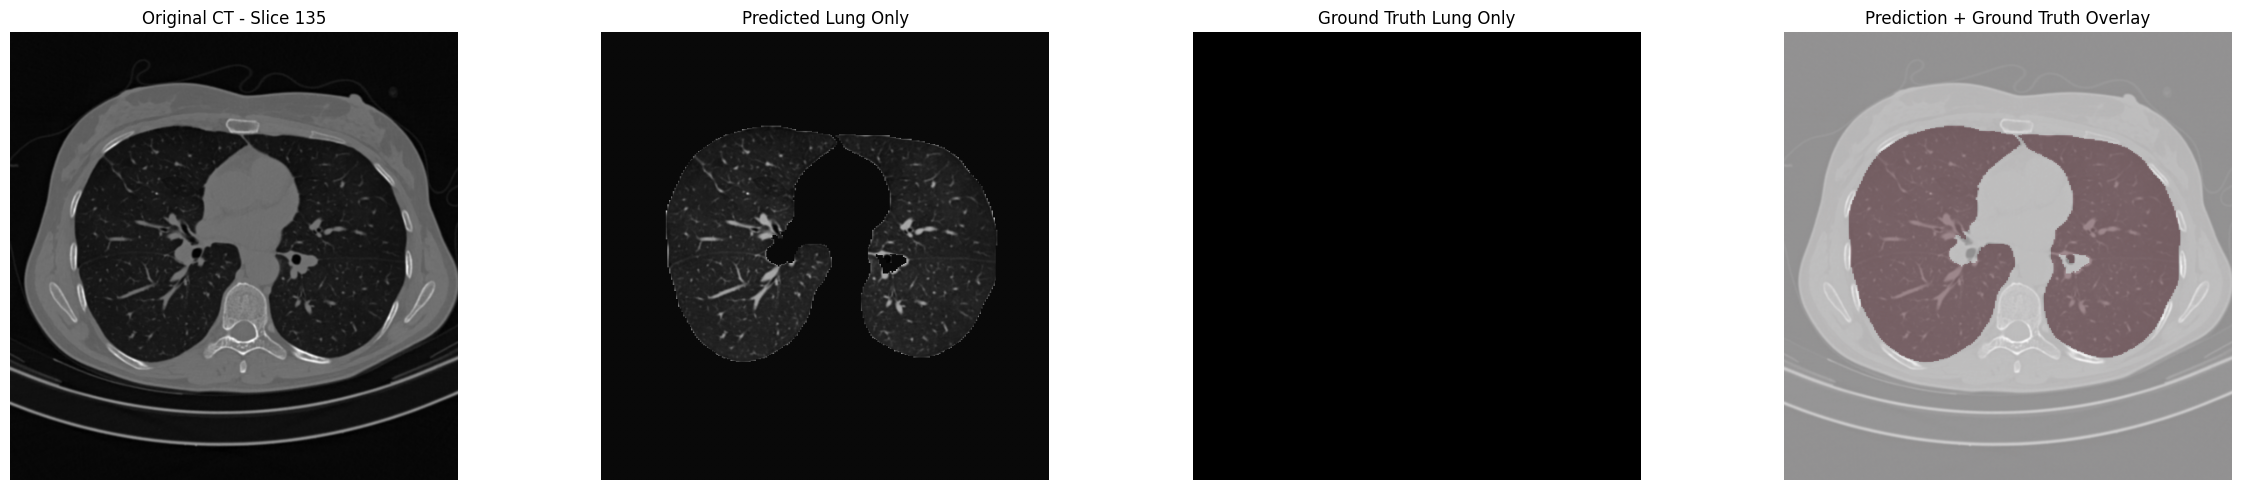

In [6]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk


# ==========================
# Load Ground Truth Mask
# ==========================

mask_path = "/home/chest_ct/code/data/segmentations/segmentations/valid_342_a_2.nii.gz"

gt_raw = nib.load(mask_path).get_fdata()

print("Raw GT shape:", gt_raw.shape)


# Combine GT channels
gt = np.any(gt_raw > 0, axis=0)

# Convert (X,Y,Z) -> (Z,Y,X)
gt = np.transpose(gt, (2,1,0))

print("GT shape:", gt.shape)



# ==========================
# Convert CT
# ==========================

ct = sitk.GetArrayFromImage(input_image)

print("CT shape:", ct.shape)



# ==========================
# Prediction mask
# ==========================

pred = segmentation > 0



# ==========================
# Find widest slice
# ==========================

slice_sizes = pred.sum(axis=(1,2))

slice_idx = np.argmax(slice_sizes)

print("Widest slice:", slice_idx)



# ==========================
# Extract slices
# ==========================

ct_slice = ct[slice_idx]

pred_slice = pred[slice_idx]

gt_slice = gt[slice_idx]



# ==========================
# Apply masks
# ==========================

pred_lung_only = ct_slice.copy()
pred_lung_only[~pred_slice] = -1000


gt_lung_only = ct_slice.copy()
gt_lung_only[~gt_slice] = -1000



# ==========================
# Visualization
# ==========================

plt.figure(figsize=(24,5))


# Original CT

plt.subplot(1,4,1)

plt.imshow(
    ct_slice,
    cmap="gray"
)

plt.title(
    f"Original CT - Slice {slice_idx}"
)

plt.axis("off")



# Predicted Lung Only

plt.subplot(1,4,2)

plt.imshow(
    pred_lung_only,
    cmap="gray"
)

plt.title(
    "Predicted Lung Only"
)

plt.axis("off")



# Ground Truth Lung Only

plt.subplot(1,4,3)

plt.imshow(
    gt_lung_only,
    cmap="gray"
)

plt.title(
    "Ground Truth Lung Only"
)

plt.axis("off")



# Prediction + GT Overlay

plt.subplot(1,4,4)

plt.imshow(
    ct_slice,
    cmap="gray"
)

# predicted mask
plt.imshow(
    pred_slice,
    cmap="Reds",
    alpha=0.35
)

# GT mask
plt.imshow(
    gt_slice,
    cmap="Blues",
    alpha=0.35
)


plt.title(
    "Prediction + Ground Truth Overlay"
)

plt.axis("off")



plt.tight_layout()

plt.show()

# Visualize

In [14]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk
from lungmask import LMInferer


# ============================================================
# Paths
# ============================================================

ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_11150_b_2.nii.gz"

pred_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/reconstructed/train_11150_b_2.nii.gz"

gt_path = "/home/chest_ct/code/data/segmentations/segmentations/train_11150_b_2.nii.gz"



# ============================================================
# Load CT (reference image)
# ============================================================

ct_img = nib.load(ct_path)

ct = np.asarray(
    ct_img.dataobj,
    dtype=np.float32
)

print("CT shape:", ct.shape)
print("CT orientation:", nib.aff2axcodes(ct_img.affine))


# ============================================================
# Load GT channel 0
# ============================================================

gt_img = nib.load(gt_path)

gt_raw = np.asarray(
    gt_img.dataobj
)

print("Original GT:", gt_raw.shape)
print("GT orientation:", nib.aff2axcodes(gt_img.affine))


# take channel 0 only
if gt_raw.ndim == 4:
    gt_raw = gt_raw[0]


gt_raw = (gt_raw > 0).astype(np.uint8)


# ============================================================
# Resample GT into CT space
# ============================================================

# Convert CT to SimpleITK
ct_sitk = sitk.ReadImage(ct_path)


# Convert GT to SimpleITK
# nibabel array is (x,y,z), SimpleITK expects (z,y,x)
gt_sitk = sitk.GetImageFromArray(
    np.transpose(gt_raw, (2,1,0))
)


# Copy GT spacing approximately from original GT
gt_spacing = gt_img.header.get_zooms()

gt_sitk.SetSpacing(
    tuple(gt_spacing)
)


# Resample GT -> CT grid
resampler = sitk.ResampleImageFilter()

resampler.SetReferenceImage(ct_sitk)

resampler.SetInterpolator(
    sitk.sitkNearestNeighbor
)

resampler.SetDefaultPixelValue(0)


gt_resampled = resampler.Execute(
    gt_sitk
)


# Back to numpy (x,y,z)
gt = sitk.GetArrayFromImage(
    gt_resampled
)

gt = np.transpose(
    gt,
    (2,1,0)
)

gt = (gt > 0).astype(np.uint8)


print("Aligned GT:", gt.shape)
print("Aligned GT voxels:", gt.sum())



# ============================================================
# Lung segmentation
# ============================================================

inferer = LMInferer(
    tqdm_disable=True
)

ct_sitk_for_lung = sitk.ReadImage(ct_path)


lung = inferer.apply(
    ct_sitk_for_lung
)


lung = sitk.GetArrayFromImage(
    lung
)

lung = np.transpose(
    lung > 0,
    (2,1,0)
)


print("Lung:", lung.shape)



# ============================================================
# Load prediction
# ============================================================

pred_crop = np.asarray(
    nib.load(pred_path).dataobj
)

pred_crop = pred_crop > 0


print("Prediction crop:", pred_crop.shape)



# ============================================================
# Put prediction into CT coordinates
# ============================================================

coords12 = np.array([
    [61,158,116],
    [61,158,120],
    [65,154,116],
    [65,154,120],
    [65,158,112],
    [65,158,116],
    [65,158,120],
    [65,162,116],
    [65,162,120],
    [69,158,116],
    [69,158,120],
    [69,162,116]
])


min_coord = coords12.min(axis=0)

print("Prediction origin:", min_coord)


pred = np.zeros_like(
    ct,
    dtype=np.uint8
)


x,y,z = min_coord


pred[
    x:x+pred_crop.shape[0],
    y:y+pred_crop.shape[1],
    z:z+pred_crop.shape[2]
] = pred_crop.astype(np.uint8)


print("Prediction voxels:", pred.sum())



# ============================================================
# Find best GT slice
# ============================================================

gt_per_slice = gt.sum(axis=(0,1))

slice_id = np.argmax(
    gt_per_slice
)


print(
    "Best slice:",
    slice_id,
    "GT voxels:",
    gt_per_slice[slice_id]
)



# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(18,5))


# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)

plt.title(
    f"CT slice {slice_id}"
)

plt.axis("off")



# Lung

plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)

plt.contour(
    lung[:,:,slice_id],
    colors="cyan"
)

plt.title(
    "CT + Lung mask"
)

plt.axis("off")



# GT vs Prediction

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)


plt.contour(
    gt[:,:,slice_id],
    colors="lime",
    linewidths=2
)


plt.contour(
    pred[:,:,slice_id],
    colors="red",
    linewidths=2
)


plt.title(
    "GT channel 0 (green) vs Prediction (red)"
)

plt.axis("off")


plt.tight_layout()
plt.show()

CT shape: (512, 512, 244)
CT orientation: ('L', 'P', 'S')
Original GT: (3, 512, 512, 244)
GT orientation: ('R', 'A', 'S')


TypeError: in method 'Image_SetSpacing', argument 2 of type 'std::vector< double,std::allocator< double > > const &'

In [15]:
def inspect_nifti(name, path):

    img = nib.load(path)

    data = np.asarray(img.dataobj)

    print("="*60)
    print(name)
    print("="*60)

    print("Shape:")
    print(data.shape)

    print("\nVoxel spacing:")
    print(img.header.get_zooms())

    print("\nOrientation:")
    print(nib.aff2axcodes(img.affine))

    print("\nAffine:")
    print(img.affine)

    print("\nData type:")
    print(data.dtype)

    print("\nNon-zero voxels:")
    print(np.count_nonzero(data))

    print("\nValue range:")
    print(data.min(), "to", data.max())

    print()



# ============================================================
# Inspect all
# ============================================================

inspect_nifti(
    "CT",
    ct_path
)


inspect_nifti(
    "GROUND TRUTH",
    gt_path
)


inspect_nifti(
    "PREDICTION",
    pred_path
)

CT
Shape:
(512, 512, 244)

Voxel spacing:
(np.float32(0.64226174), np.float32(0.64226174), np.float32(1.25))

Orientation:
('L', 'P', 'S')

Affine:
[[-6.42261744e-01  0.00000000e+00  0.00000000e+00  1.75178864e+02]
 [ 0.00000000e+00 -6.42261744e-01  0.00000000e+00  3.63597870e+02]
 [ 0.00000000e+00  0.00000000e+00  1.25000000e+00 -1.18412598e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Data type:
int16

Non-zero voxels:
63860776

Value range:
-1156 to 2351

GROUND TRUTH
Shape:
(3, 512, 512, 244)

Voxel spacing:
(np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(0.0))

Orientation:
('R', 'A', 'S')

Affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Data type:
uint8

Non-zero voxels:
25969

Value range:
0 to 1

PREDICTION
Shape:
(20, 20, 20)

Voxel spacing:
(np.float32(1.0), np.float32(1.0), np.float32(1.0))

Orientation:
('R', 'A', 'S')

Affine:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Data type:
uint16

No

In [16]:
import nibabel as nib
import numpy as np

gt_img = nib.load(gt_path)

gt = gt_img.get_fdata()

# channel 0
gt0 = gt[0]

coords = np.argwhere(gt0 > 0)

print("GT min coords:", coords.min(axis=0))
print("GT max coords:", coords.max(axis=0))
print("GT size:", coords.max(axis=0)-coords.min(axis=0)+1)

GT min coords: [149 368 143]
GT max coords: [178 401 153]
GT size: [30 34 11]


NameError: name 'slice_id' is not defined

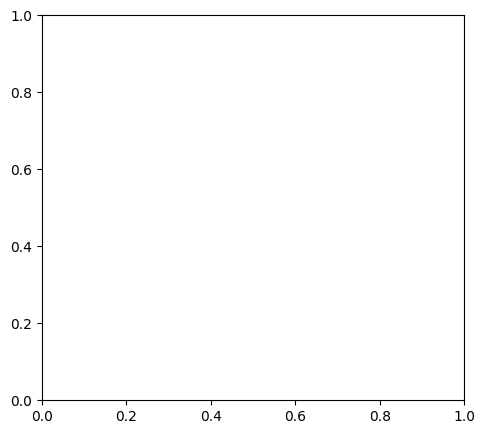

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(ct[:,:,slice_id], cmap="gray")
plt.contour(
    lung[:,:,slice_id],
    colors="cyan"
)
plt.title("Lung")

plt.subplot(1,2,2)
plt.imshow(ct[:,:,slice_id], cmap="gray")
plt.contour(
    gt[:,:,slice_id],
    colors="lime"
)
plt.title("GT")

plt.show()

In [ ]:
# ============================================================
# Find slice with maximum predicted voxels
# ============================================================

pred_per_slice = pred.sum(axis=(0,1))

pred_slice = np.argmax(pred_per_slice)

print(
    "Prediction max slice:",
    pred_slice,
    "Pred voxels:",
    pred_per_slice[pred_slice]
)


# Also print GT voxels on this slice
print(
    "GT voxels on prediction slice:",
    gt[:,:,pred_slice].sum()
)


# ============================================================
# Visualize prediction max slice
# ============================================================

slice_id = pred_slice


plt.figure(figsize=(18,5))


# CT
plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)

plt.title(
    f"CT slice {slice_id}"
)

plt.axis("off")



# Prediction only
plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)

plt.contour(
    pred[:,:,slice_id],
    colors="red",
    linewidths=2
)

plt.title(
    f"LC-KSVD Prediction\nvoxels={pred_per_slice[slice_id]}"
)

plt.axis("off")



# Prediction + GT
plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_id],
    cmap="gray"
)


# GT green
plt.contour(
    gt[:,:,slice_id],
    colors="lime",
    linewidths=2
)


# Prediction red
plt.contour(
    pred[:,:,slice_id],
    colors="red",
    linewidths=2
)


plt.title(
    "GT (green) vs Prediction (red)"
)

plt.axis("off")


plt.tight_layout()
plt.show()